In [12]:
!pip install -q langchain-huggingface langchain-qdrant sentence-transformers numpy pandas


In [ ]:

import json, os, time
from pathlib import Path

import numpy as np
import pandas as pd
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import QdrantVectorStore

# ── Credentials ───────────────────────────────────────────────
QDRANT_URL     = ""
QDRANT_API_KEY = ""

# ── Eval dataset (upload this file to Colab) ──────────────────
EVAL_PATH = Path("/content/eval_queries_multi_chunk.json")
K = 10   # retrieve top-K docs per query

# ── Models: name → (HuggingFace model path, Qdrant collection) ─
MODELS = {
    "bge-m3":           ("BAAI/bge-m3",                             "ada_model_bge_m3"),
    "e5-large-v2":      ("intfloat/e5-large-v2",                    "ada_model_e5_large_v2"),
    "MedEmbed":         ("abhinand/MedEmbed-base-v0.1",             "ada_model_medembed_base_v0.1"),
    "e5-base-v2":       ("intfloat/e5-base-v2",                     "ada_model_e5_base_v2"),
    "pubmedbert":       ("NeuML/pubmedbert-base-embeddings",        "ada_model_pubmedbert_base_embeddings"),
    "all-mini":         ("sentence-transformers/all-MiniLM-L6-v2",  "ada_model_all_mini"),
    "Bio_ClinicalBERT": ("emilyalsentzer/Bio_ClinicalBERT",         "ada_model_bio_clinicalbert"),
}

# ── Load eval queries ─────────────────────────────────────────
with open(EVAL_PATH) as f:
    eval_queries = json.load(f)

print(f"✓ Loaded {len(eval_queries)} queries from {EVAL_PATH.name}")

✓ Loaded 30 queries from eval_queries_multi_chunk.json


In [14]:
def precision_at_k(retrieved: list, relevant: list, k: int = 5) -> float:
    return len(set(retrieved[:k]) & set(relevant)) / k

def recall_at_k(retrieved: list, relevant: list, k: int = 10) -> float:
    if not relevant:
        return 0.0
    return len(set(retrieved[:k]) & set(relevant)) / len(relevant)

def mrr(retrieved: list, relevant: list) -> float:
    rel_set = set(relevant)
    for i, cid in enumerate(retrieved, 1):
        if cid in rel_set:
            return 1.0 / i
    return 0.0

def ndcg_at_k(retrieved: list, scores: dict, k: int = 5) -> float:
    dcg  = sum(scores.get(cid, 0) / np.log2(i + 1)
               for i, cid in enumerate(retrieved[:k], 1))
    idcg = sum(s / np.log2(i + 1)
               for i, s in enumerate(sorted(scores.values(), reverse=True)[:k], 1))
    return dcg / idcg if idcg > 0 else 0.0

def hit_at_k(retrieved: list, relevant: list, k: int = 5) -> float:
    return 1.0 if set(retrieved[:k]) & set(relevant) else 0.0

In [ ]:
all_results = []

for model_name, (model_path, collection_name) in MODELS.items():
    print(f"\n{'='*60}")
    print(f"Model      : {model_name}")
    print(f"Collection : {collection_name}")
    print(f"{'='*60}")

    # Load embedding model (downloads on first run, cached after)
    embeddings = HuggingFaceEmbeddings(
        model_name=model_path,
        model_kwargs={"device": "cpu"},
        encode_kwargs={"normalize_embeddings": True},
    )

    # Connect to Qdrant
    vector_store = QdrantVectorStore.from_existing_collection(
        collection_name=collection_name,
        embedding=embeddings,
        url=QDRANT_URL,
        api_key=QDRANT_API_KEY,
    )

    p5_list, r10_list, mrr_list, ndcg5_list, hit5_list, lat_list = [], [], [], [], [], []

    for i, item in enumerate(eval_queries, 1):
        query          = item["query"]
        relevant_ids   = item["ground_truth"]["relevant_chunk_ids"]
        rel_scores     = item["ground_truth"]["relevance_scores"]

        # Retrieve
        t0   = time.time()
        docs = vector_store.similarity_search(query, k=K)
        lat  = time.time() - t0

        retrieved_ids = [doc.metadata.get("chunk_id") for doc in docs]

        p5    = precision_at_k(retrieved_ids, relevant_ids, k=5)
        r10   = recall_at_k(retrieved_ids, relevant_ids, k=10)
        mrr_s = mrr(retrieved_ids, relevant_ids)
        ndcg5 = ndcg_at_k(retrieved_ids, rel_scores, k=5)
        hit5  = hit_at_k(retrieved_ids, relevant_ids, k=5)

        p5_list.append(p5);  r10_list.append(r10);  mrr_list.append(mrr_s)
        ndcg5_list.append(ndcg5);  hit5_list.append(hit5);  lat_list.append(lat)

        print(f"  [{i:02d}] P@5={p5:.2f} NDCG@5={ndcg5:.2f} Hit@5={int(hit5)} | {lat*1000:.0f}ms | {query[:55]}...")

    result = {
        "Model":        model_name,
        "Precision@5":  round(float(np.mean(p5_list)),   3),
        "Recall@10":    round(float(np.mean(r10_list)),  3),
        "MRR":          round(float(np.mean(mrr_list)),  3),
        "NDCG@5":       round(float(np.mean(ndcg5_list)),3),
        "Hit@5":        round(float(np.mean(hit5_list)), 3),
        "Latency_ms":   round(float(np.mean(lat_list)) * 1000, 1),
    }
    all_results.append(result)

    print(f"\n  Precision@5 : {result['Precision@5']}")
    print(f"  Recall@10   : {result['Recall@10']}")
    print(f"  MRR         : {result['MRR']}")
    print(f"  NDCG@5      : {result['NDCG@5']}")
    print(f"  Hit@5       : {result['Hit@5']}")
    print(f"  Latency     : {result['Latency_ms']} ms")


In [16]:
df = (pd.DataFrame(all_results)
        .sort_values("NDCG@5", ascending=False)
        .reset_index(drop=True))

print("\n" + "="*70)
print("FINAL RESULTS — sorted by NDCG@5")
print("="*70)
print(df.to_string(index=False))


FINAL RESULTS — sorted by NDCG@5
           Model  Precision@5  Recall@10   MRR  NDCG@5  Hit@5  Latency_ms
        MedEmbed        0.393      0.562 0.797   0.511  0.867       249.8
        all-mini        0.380      0.518 0.743   0.470  0.867       101.8
     e5-large-v2        0.373      0.514 0.685   0.449  0.867       826.0
          bge-m3        0.353      0.531 0.724   0.436  0.800       866.3
      pubmedbert        0.287      0.457 0.609   0.381  0.733       232.4
      e5-base-v2        0.307      0.440 0.552   0.376  0.767       248.1
Bio_ClinicalBERT        0.120      0.190 0.286   0.145  0.433       323.8


In [17]:
csv_path = "/content/embedding_evaluation_results.csv"
df.to_csv(csv_path, index=False)

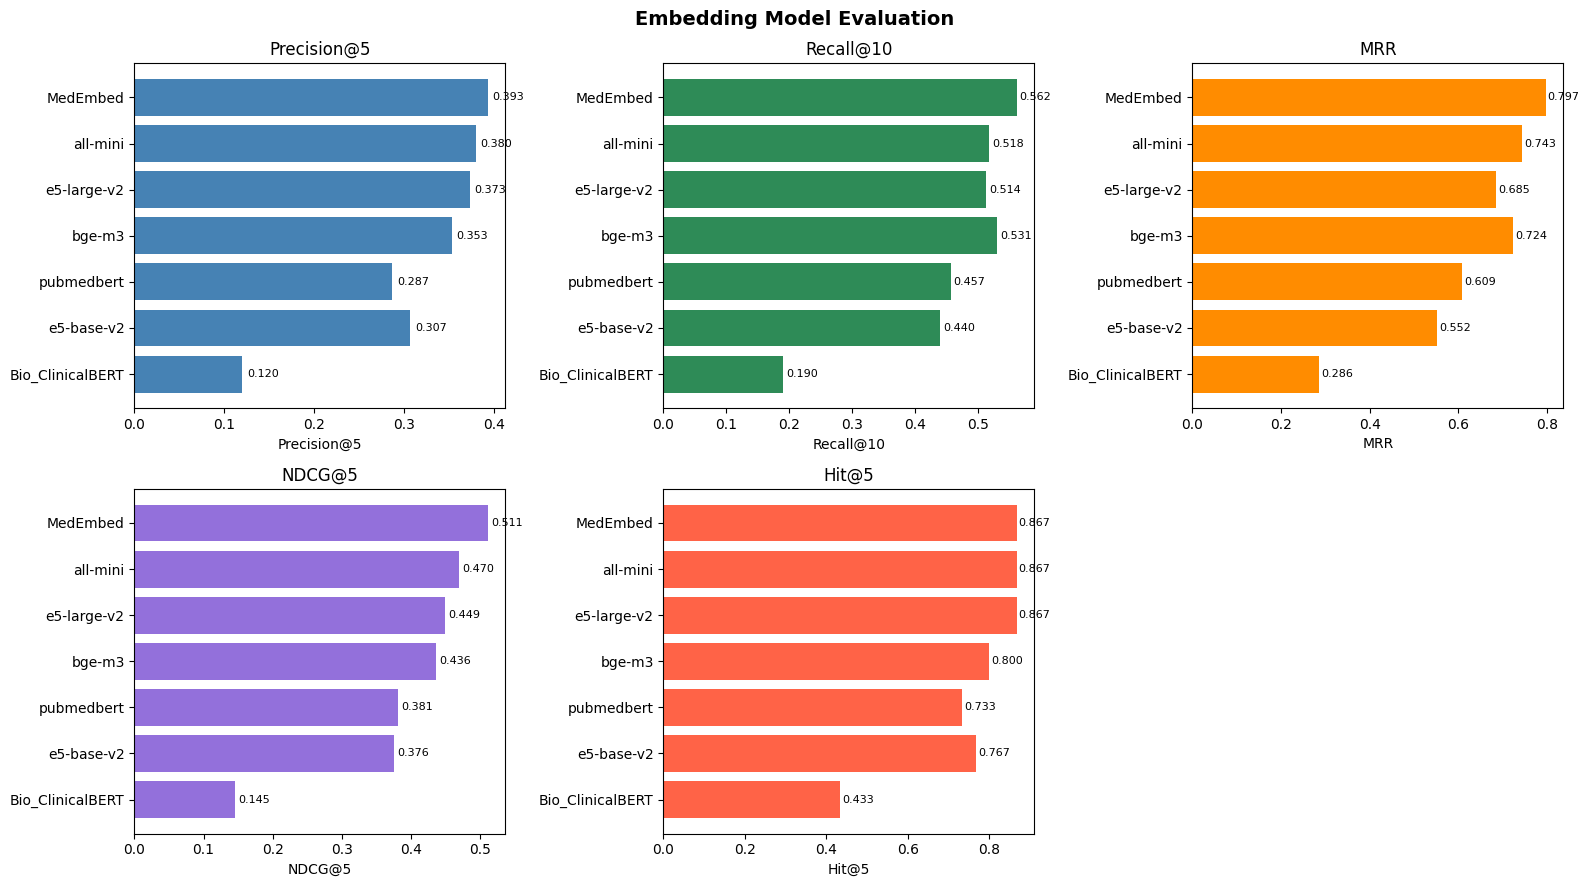

In [19]:
import matplotlib.pyplot as plt

metrics = ["Precision@5", "Recall@10", "MRR", "NDCG@5", "Hit@5"]
colors  = ["steelblue", "seagreen", "darkorange", "mediumpurple", "tomato"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, metric, color in zip(axes, metrics, colors):
    ax.barh(df["Model"], df[metric], color=color)
    ax.set_xlabel(metric)
    ax.set_title(metric)
    ax.invert_yaxis()
    for i, v in enumerate(df[metric]):
        ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)

axes[-1].axis("off")   # hide unused 6th panel
plt.suptitle("Embedding Model Evaluation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/embedding_evaluation_charts.png", dpi=150, bbox_inches="tight")
plt.show()